In [1]:
import torch
from torch import nn
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from pinn.lib import SchrodingerData, SchrodingerModel, get_loss, Util, get_bayesian_loss
from pinn.bayesian import BayesianFCN

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [3]:
import os

os.makedirs("Data", exist_ok=True)

import requests

url = "https://github.com/maziarraissi/PINNs/raw/master/main/Data/NLS.mat"
r = requests.get(url)

with open("Data/NLS.mat", "wb") as f:
    f.write(r.content)

print("Downloaded NLS.mat to Data/NLS.mat")

Downloaded NLS.mat to Data/NLS.mat


In [4]:
data = scipy.io.loadmat('Data/NLS.mat')

t_np = data['tt'].flatten()[:,None]
x_np = data['x'].flatten()[:,None]
Exact = data['uu']
Exact_u = np.real(Exact)
Exact_v = np.imag(Exact)

In [5]:
t_np.shape, x_np.shape, Exact.shape

((201, 1), (256, 1), (256, 201))

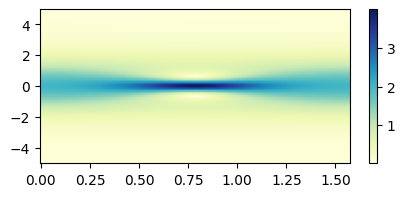

In [6]:
T_np, X_np = np.meshgrid(t_np.squeeze(), x_np.squeeze())

plt.figure(figsize=(5,2))
plt.pcolormesh(T_np, X_np, np.abs(Exact), cmap="YlGnBu")
plt.colorbar()
plt.show()

In [7]:
torch.cuda.manual_seed(42)
torch.manual_seed(42)

In [8]:
util = Util()
schrodinger_data = SchrodingerData(util,
                                   Exact,
                                   x_np,
                                   n_data=50,
                                   n_boundary=50,
                                   n_collocation=20000,
                                   t_bound=[0, torch.pi / 2],
                                   x_bound=[-5, 5]
                                  )

In [139]:
clip_norm = 1
beta_scaling = 1e-3
lr = 1e-3

epochs = 1000
schrodinger_model = BayesianFCN(n_input=2,n_layer=3, n_out=2, t_bound=[0, torch.pi / 2],
                                   x_bound=[-5, 5], prior_std=1)
optimizer = torch.optim.Adam(schrodinger_model.parameters(), lr=lr)
schrodinger_model.to(device)

BayesianFCN(
  (first): Sequential(
    (0): BayesianLinear()
    (1): Tanh()
  )
  (hidden): ModuleList(
    (0-2): 3 x Sequential(
      (0): BayesianLinear()
      (1): Tanh()
    )
  )
  (last): BayesianLinear()
)

In [17]:
load = torch.load("Bayesian/schrodinger_model-29000.pt", map_location=device)
schrodinger_model.load_state_dict(
    load["model_state_dict"]
)

<All keys matched successfully>

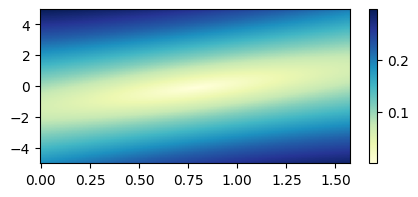

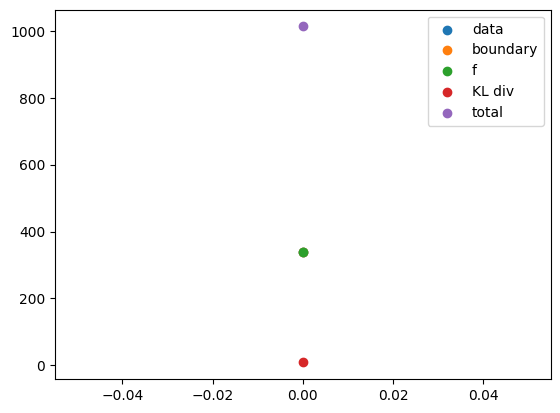

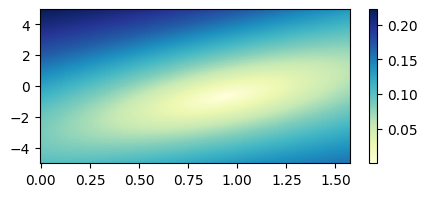

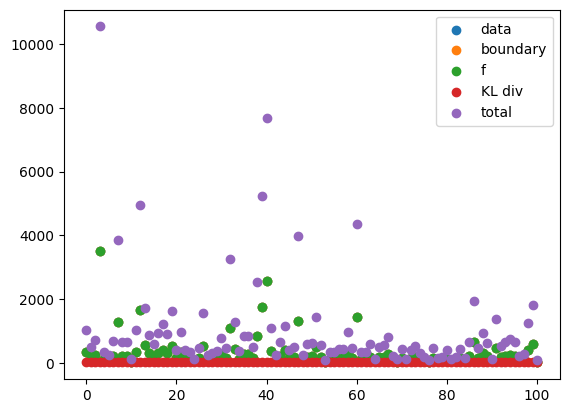

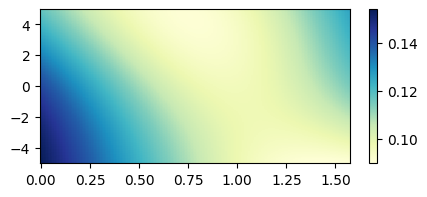

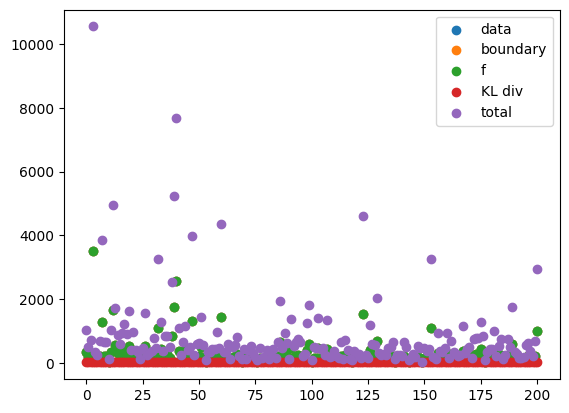

KeyboardInterrupt: 

In [11]:
data_losses = []
boundary_losses = []
f_losses = []
kl_divergences = []
for i in range(epochs):
    optimizer.zero_grad()

    mc = 4
    data_loss = boundary_loss = f_loss = torch.tensor(0.0)
    for _ in range(mc):
        dl, bl, fl = get_loss(schrodinger_model, schrodinger_data)
        data_loss += dl / mc; boundary_loss += bl / mc; f_loss += fl / mc
    
    kl_divergence = beta_scaling * schrodinger_model.kl_divergence()
    loss = data_loss + boundary_loss + f_loss + kl_divergence

    loss.backward()

    torch.nn.utils.clip_grad_norm_(schrodinger_model.parameters(), clip_norm)
    
    optimizer.step()

    data_losses.append(data_loss.item())
    
    boundary_losses.append(boundary_loss.item())

    f_losses.append(f_loss.item())

    kl_divergences.append(kl_divergence.item())

    if i % max(1, epochs // 10) == 0:
        T_np, X_np = np.meshgrid(t_np.flatten(), x_np.flatten())
        pairs = torch.tensor(np.column_stack([X_np.ravel(), T_np.ravel()]), device=device, dtype=torch.float)

        result = schrodinger_model(torch.tensor(X_np.ravel(), dtype=torch.float), torch.tensor(T_np.ravel(), dtype=torch.float), sample=False)

        np_result = np.abs(result.detach().cpu().numpy()[:,1] * 1j + result.detach().cpu().numpy()[:,0])

        plt.figure(figsize=(5,2))
        plt.pcolormesh(T_np, X_np, np_result.reshape(x_np.shape[0], t_np.shape[0]), cmap="YlGnBu")
        plt.colorbar()
        plt.show()
        plt.scatter(np.arange(len(data_losses)), np.array(data_losses), label="data")
        plt.scatter(np.arange(len(boundary_losses)), np.array(boundary_losses), label="boundary")
        plt.scatter(np.arange(len(f_losses)), np.array(f_losses), label="f")
        plt.scatter(np.arange(len(kl_divergences)), np.array(kl_divergences), label="KL div")
        plt.scatter(np.arange(len(boundary_losses)), np.array(boundary_losses) + np.array(data_losses) + np.array(f_losses), label="total")
        plt.legend()
        plt.show()



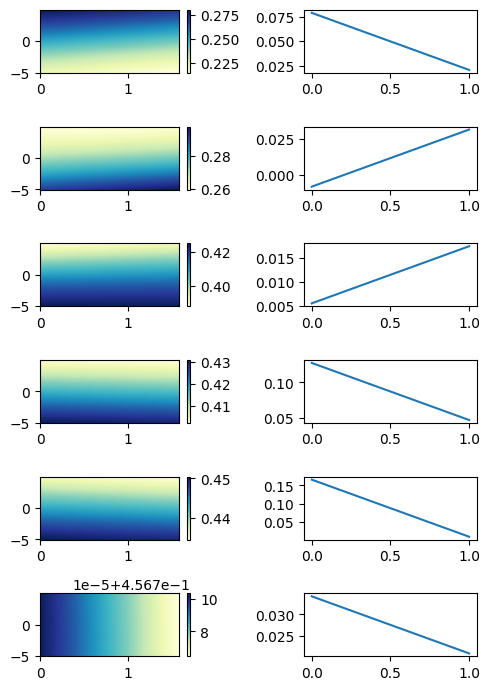

In [133]:
plt.figure(figsize=(5,7))
start = 2000
params = []
for i in range(6):
    load = torch.load(f"Bayesian/schrodinger_model-{start + i * 1000}.pt", map_location=device)
    schrodinger_model.load_state_dict(
        load["model_state_dict"]
    )
    params.append(next(iter(schrodinger_model.parameters()))[0])
    result = schrodinger_model(torch.tensor(X_np.ravel(), dtype=torch.float), torch.tensor(T_np.ravel(), dtype=torch.float), sample=False)
    np_result = np.abs(result.detach().cpu().numpy()[:,1] * 1j + result.detach().cpu().numpy()[:,0])
    
    plt.subplot(6, 2, 2*(i) + 1)
    plt.pcolormesh(T_np, X_np, np_result.reshape(x_np.shape[0], t_np.shape[0]), cmap="YlGnBu")
    plt.colorbar()

    plt.subplot(6, 2, 2*(i) + 2)
    parameters = next(iter(schrodinger_model.parameters()))[1]
    plt.plot(np.arange(len(parameters)), parameters.detach().cpu().numpy())

plt.tight_layout()
plt.show()


In [116]:
import math
import torch.nn.functional as F
from typing import List

class BayesianLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int, prior_std: float):
        super().__init__()
        # Mean and log variance of weight distribution
        self.weight_mu = nn.Parameter(torch.Tensor(out_features, in_features).normal_(0, 0.1))
        self.weight_logvar = nn.Parameter(torch.Tensor(out_features, in_features).normal_(-3, 0.1))
        self.bias_mu = nn.Parameter(torch.zeros(out_features))
        self.bias_logvar = nn.Parameter(torch.ones(out_features) * -3)
        self.prior_std = prior_std

    def forward(self, x, sample: bool = True):
        if sample:
            weight_eps = torch.randn_like(self.weight_mu)
            bias_eps = torch.randn_like(self.bias_mu)
            weight = self.weight_mu + torch.exp(0.5 * self.weight_logvar) * weight_eps
            bias = self.bias_mu + torch.exp(0.5 * self.bias_logvar) * bias_eps
        else:
            weight = self.weight_mu
            bias  = self.bias_mu
        return F.linear(x, weight, bias)
    
    def kl_divergence(self) -> torch.Tensor:
        prior_var = self.prior_std ** 2
        post_var = torch.exp(self.weight_logvar)
        kl = 0.5 * (
            (post_var + self.weight_mu**2) / prior_var
            - 1
            + math.log(prior_var) - self.weight_logvar
        ).sum()
        # same for bias
        post_var_bias = torch.exp(self.bias_logvar)
        kl += 0.5 * (
            (post_var_bias + self.bias_mu**2) / prior_var
            - 1
            + math.log(prior_var) - self.bias_logvar
        ).sum()
        return kl
    
class BayesianFCN(nn.Module):
    """A simple fully-connected neural net for solving equations.

    In this model, lower and upper bound will be used for normalization of input data
    """
    output_names: List[str]
    
    def __init__(self, n_input: int, n_layer: int, n_out: int, x_bound: list[float], t_bound: list[float], prior_std=0.1) -> None:
        """Initialize a `FCN` module.

        :param layers: The list indicating number of neurons in each layer.
        :param lb: Lower bound for the inputs.
        :param ub: Upper bound for the inputs.
        :param output_names: Names of outputs of net.
        :param discrete: If the problem is discrete or not.
        """
        super().__init__()
        n_hidden = 50
        self.x_lb: torch.Tensor
        self.x_ub: torch.Tensor
        self.t_lb: torch.Tensor
        self.t_ub: torch.Tensor
        # store bounds for scaling
        self.register_buffer("x_lb", torch.tensor(x_bound[0], dtype=torch.float32))
        self.register_buffer("x_ub", torch.tensor(x_bound[1], dtype=torch.float32))
        self.register_buffer("t_lb", torch.tensor(t_bound[0], dtype=torch.float32))
        self.register_buffer("t_ub", torch.tensor(t_bound[1], dtype=torch.float32))
        
        self.first = self.block(n_input, n_hidden, prior_std)
        self.hidden: nn.ModuleList = nn.ModuleList([self.block(n_hidden, n_hidden, prior_std) for _ in range(n_layer)])
        self.last = BayesianLinear(n_hidden, n_out, prior_std=prior_std)

        self.apply(self._init_weights)

    def block(self, n_input, n_hidden, prior_std) -> nn.Sequential:
        return nn.Sequential(*[
            BayesianLinear(n_input, n_hidden, prior_std),
            nn.Tanh()
        ])
    
    def _init_weights(self, module):
        """Apply Xavier initialization to linear layers"""
        if isinstance(module, BayesianLinear):
            # Xavier uniform initialization (also called Glorot uniform)
            nn.init.xavier_uniform_(module.weight_mu)
            if module.bias_mu is not None:
                nn.init.zeros_(module.bias_mu)

    def forward(self, x, t, sample=True) -> torch.Tensor:
        x_scaled = 2.0 * (x - self.x_lb) / (self.x_ub - self.x_lb) - 1.0
        t_scaled = 2.0 * (t - self.t_lb) / (self.t_ub - self.t_lb) - 1.0
        X = torch.stack([x_scaled, t_scaled], dim=1)
        h = self.first[0](X, sample)  # BayesianLinear
        h = self.first[1](h)          # Tanh
        for layer in self.hidden:
            h = layer[0](h, sample)
            h = layer[1](h)
        
        return self.last(h, sample)

    def kl_divergence(self):
        kl = torch.tensor(0.0, device=next(self.parameters()).device)
        for m in self.modules():
            if isinstance(m, BayesianLinear):
                kl += m.kl_divergence()
        return kl



In [122]:
torch.manual_seed(42)
t_low_boundary, x_low_boundary, t_high_boundary, x_high_boundary = schrodinger_data.sample_boundary()

linear = BayesianLinear(2, 100, 0.1)
linear_h = BayesianLinear(100, 100, 0.1)

nn.init.xavier_uniform_(linear.weight_mu)
nn.init.zeros_(linear.bias_mu)
nn.init.xavier_uniform_(linear_h.weight_mu)
nn.init.zeros_(linear_h.bias_mu)

prior_std = 0.01

bayesian_fcn = BayesianFCN(n_input=2,n_layer=3, n_out=2, t_bound=[0, torch.pi / 2],
                                       x_bound=[-5, 5], prior_std=prior_std)

t_bound=[0, torch.pi / 2]
x_bound=[-5, 5]
x_lb = x_bound[0]
x_ub = x_bound[1]
t_lb = t_bound[0]
t_ub = t_bound[1]

x = x_low_boundary
t = t_low_boundary
X = torch.stack([x_low_boundary, t_low_boundary], dim=1)

x_scaled = 2.0 * (x - x_lb) / (x_ub - x_lb) - 1.0
t_scaled = 2.0 * (t - t_lb) / (t_ub - t_lb) - 1.0

X = torch.stack([x_scaled, t_scaled], dim=1)
y = linear(X)
# plt.hist(y.reshape(-1).detach(), bins=50)
# for i in range(4):
#     y = linear_h(y)
#     y = nn.Tanh()(y)

# saturation = torch.count_nonzero(y.reshape(-1) > 0.99) / len(y.reshape(-1))
# plt.hist(y.reshape(-1).detach(), bins=50), saturation
# y.shape, torch.cov(y).shape
loss = get_loss(bayesian_fcn, schrodinger_data)
kl = bayesian_fcn.kl_divergence()
kl

tensor(2743115.7500, grad_fn=<AddBackward0>)

In [150]:
load = torch.load("Bayesian/schrodinger_model-3000.pt", map_location=device)
schrodinger_model.load_state_dict(
    load["model_state_dict"]
)

<All keys matched successfully>

In [151]:
kl = 0
for m in schrodinger_model.modules():
    if isinstance(m, BayesianLinear):
        print([param for param in m.named_parameters()])
        kl += m.kl_divergence()
        print(m.kl_divergence())
kl

[('weight_mu', Parameter containing:
tensor([[-0.1533,  0.0046],
        [-0.0082,  0.0317],
        [-0.0959,  0.0303],
        [-0.1405,  0.0074],
        [-0.0094, -0.0389],
        [-0.0679,  0.0257],
        [ 0.0114,  0.0187],
        [-0.0516,  0.0219],
        [-0.1019,  0.0201],
        [ 0.2514, -0.0117],
        [-0.0266,  0.0024],
        [ 0.0064, -0.0271],
        [ 0.1343,  0.0066],
        [ 0.1051,  0.0399],
        [-0.0791, -0.0475],
        [-0.0368,  0.0148],
        [ 0.0871, -0.0187],
        [-0.0848, -0.0474],
        [ 0.1707, -0.0181],
        [ 0.0470,  0.0068],
        [ 0.1781, -0.0294],
        [-0.1210, -0.0757],
        [-0.1150,  0.0704],
        [ 0.0288,  0.0322],
        [ 0.0144,  0.0162],
        [ 0.1277, -0.0065],
        [-0.0825,  0.0280],
        [ 0.0870, -0.0204],
        [ 0.0222, -0.0327],
        [-0.0809, -0.0182],
        [-0.3051, -0.0113],
        [ 0.0169,  0.0968],
        [-0.0159,  0.0083],
        [ 0.1386,  0.0129],
        [ 0

tensor(8693.3555, grad_fn=<AddBackward0>)